# EN 3150 Pattern Recognition



In [22]:
## Import Libraries and dataset from scikit-learn

import pandas as pd
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt

diabetes = load_diabetes(as_frame=True)

Features = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
Target = pd.DataFrame(diabetes.target, columns=["target"])


In [23]:
Features_names = Features.columns
print("Features names: ", Features_names)
print(Features.describe())
print(Target.describe())

Missing_value_columns = Features.isnull().sum()
print("Missing value columns: ", Missing_value_columns)
## There are no missing values in the dataset.

## check for skewness in the dataset
skewness = Features.skew()
print("Skewness of each feature:")
print(skewness)

## Check for target skewness
target_skewness = Target.skew()
print("Skewness of target variable:")
print(target_skewness)  

## check for any categorical features in the dataset
cat = [cname for cname in Features.columns if Features[cname].dtype == 'object']
print("Categorical features: ", cat)
## There are no categorical features in the dataset.



Features names:  Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='str')
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  
mean   3.918434e-17 -5.777179e-

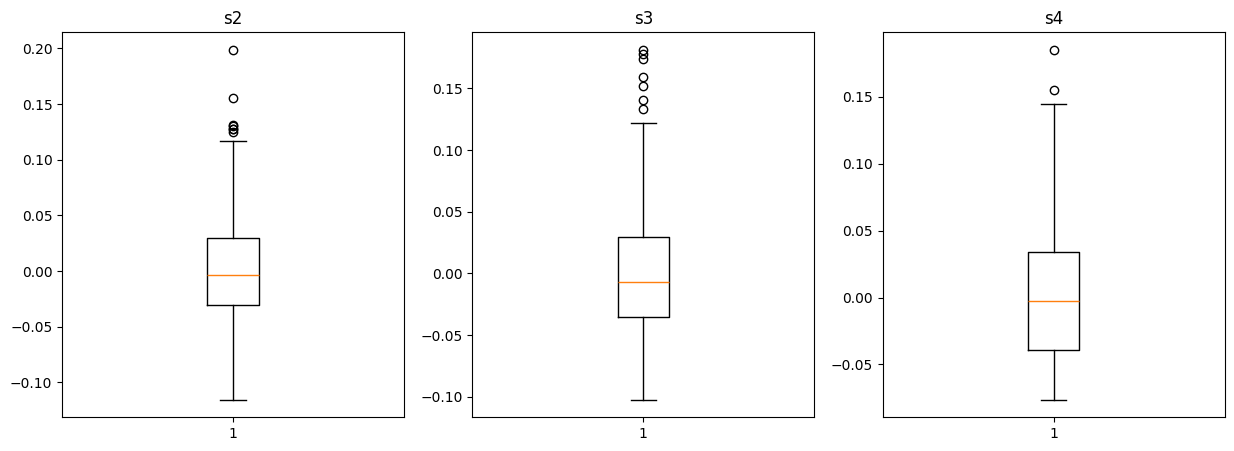

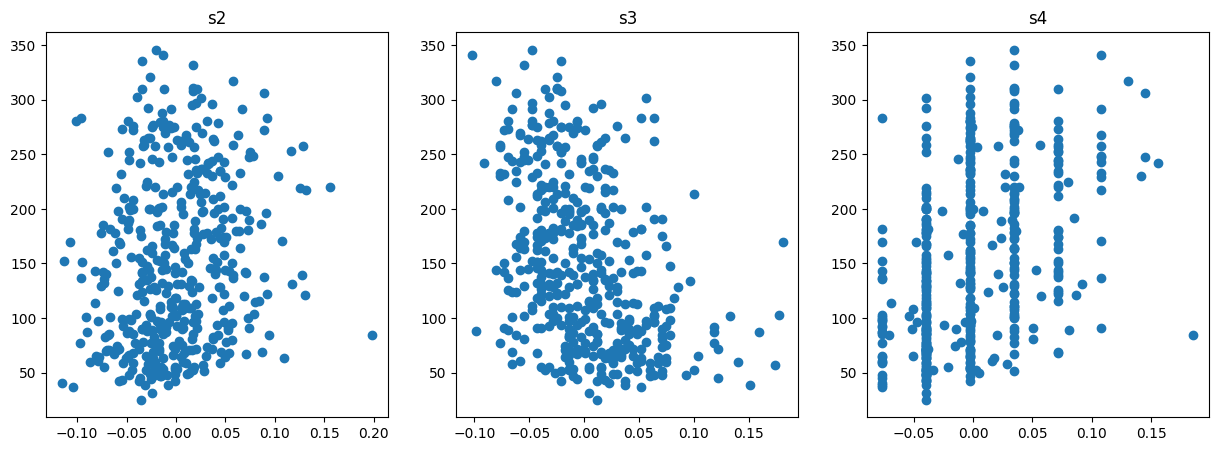

In [24]:
## selecting the features that may contain outliers based on statistics and skewness.
# based on the skewness and statistics, we can select the features that may contain outliers. The features with high skewness and extreme values in the statistics are likely to contain outliers.
Selected_features = ['s2', 's3', 's4']

# visualize the data of the features
# boxplot
fig,ax = plt.subplots(1,3,figsize=(15,5))
for i, feature in enumerate(Selected_features):
    ax[i].boxplot(Features[feature])
    ax[i].set_title(feature)    

#scatter plot
fig,ax = plt.subplots(1,3,figsize=(15,5))
for i, feature in enumerate(Selected_features):
    ax[i].scatter(Features[feature], Target)
    ax[i].set_title(feature)





In [25]:
## Use different normalization techniques to normalize the data and visualize the data after normalization. The normalization techniques that can be used are Min-Max normalization, Z-score normalization, and Robust normalization.
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, PowerTransformer

Min_max_scaler = MinMaxScaler()
Standard_scaler = StandardScaler()  
Robust_scaler = RobustScaler()  
Power_scaler = PowerTransformer()

Min_max_scaled = Min_max_scaler.fit_transform(Features[Selected_features])
Standard_scaled = Standard_scaler.fit_transform(Features[Selected_features])
Robust_scaled = Robust_scaler.fit_transform(Features[Selected_features])
Power_scaled = Power_scaler.fit_transform(Features[Selected_features])



Text(0.5, 1.0, 'Power Normalization')

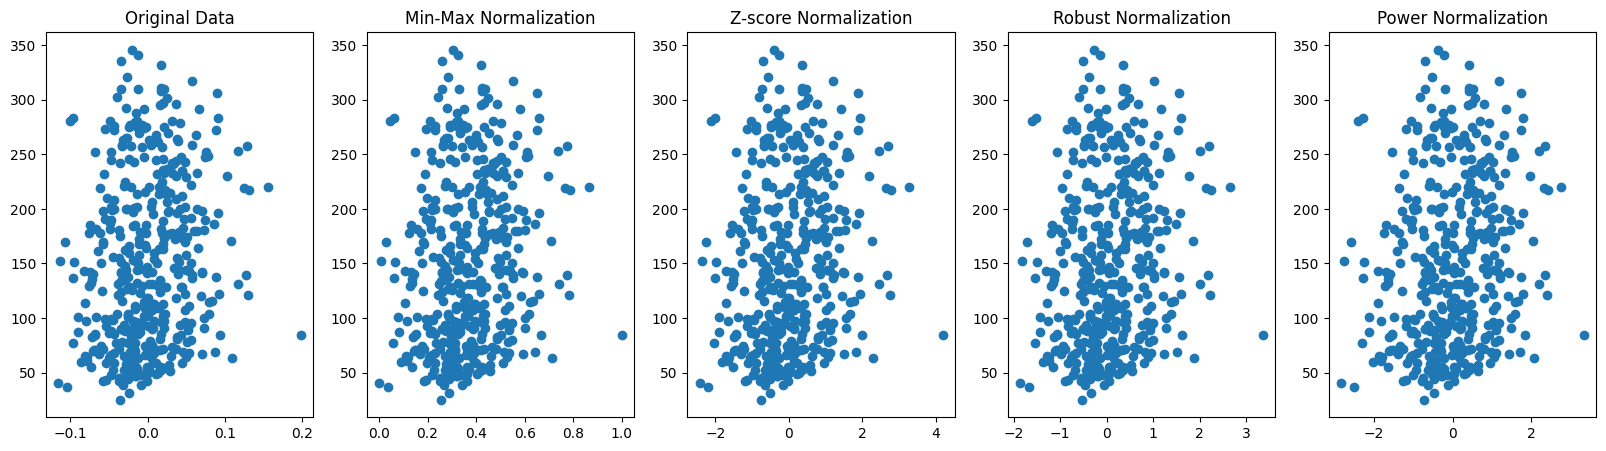

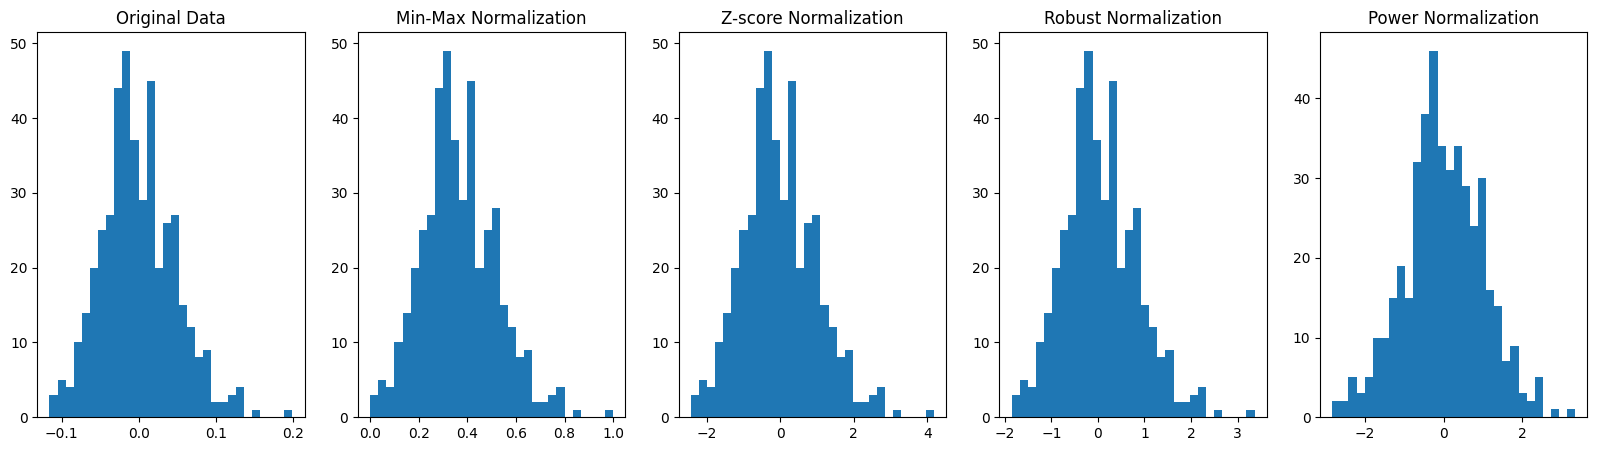

In [30]:
# Visualize the data after normalization using boxplot and scatter plot for each normalization technique.

#feature S2 scatter plots
fig,ax = plt.subplots(1,5,figsize=(20,5))
ax[0].scatter(Features[Selected_features[0]],Target)
ax[0].set_title("Original Data")
ax[1].scatter(Min_max_scaled[:,0],Target)
ax[1].set_title("Min-Max Normalization")
ax[2].scatter(Standard_scaled[:,0],Target)
ax[2].set_title("Z-score Normalization")
ax[3].scatter(Robust_scaled[:,0],Target)
ax[3].set_title("Robust Normalization")
ax[4].scatter(Power_scaled[:,0],Target)
ax[4].set_title("Power Normalization")

#feature S2 histograms
fig,ax = plt.subplots(1,5,figsize=(20,5))
ax[0].hist(Features[Selected_features[0]], bins=30)
ax[0].set_title("Original Data")
ax[1].hist(Min_max_scaled[:,0], bins=30)
ax[1].set_title("Min-Max Normalization")
ax[2].hist(Standard_scaled[:,0], bins=30)
ax[2].set_title("Z-score Normalization")
ax[3].hist(Robust_scaled[:,0], bins=30)
ax[3].set_title("Robust Normalization")
ax[4].hist(Power_scaled[:,0], bins=30)
ax[4].set_title("Power Normalization")


Text(0.5, 1.0, 'Power Normalization')

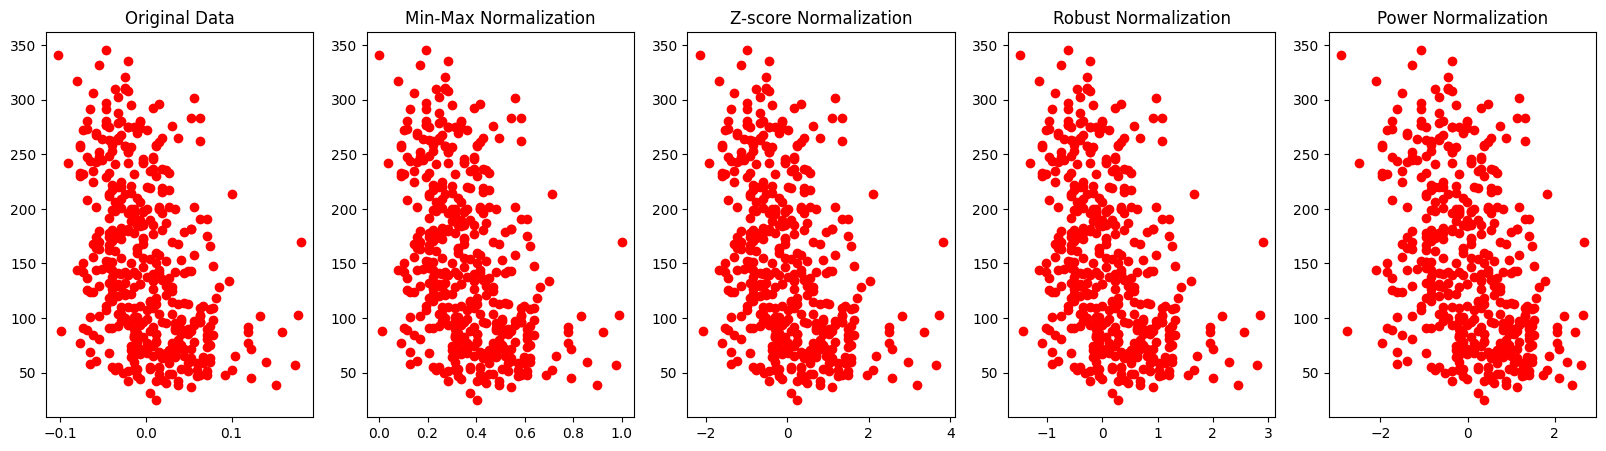

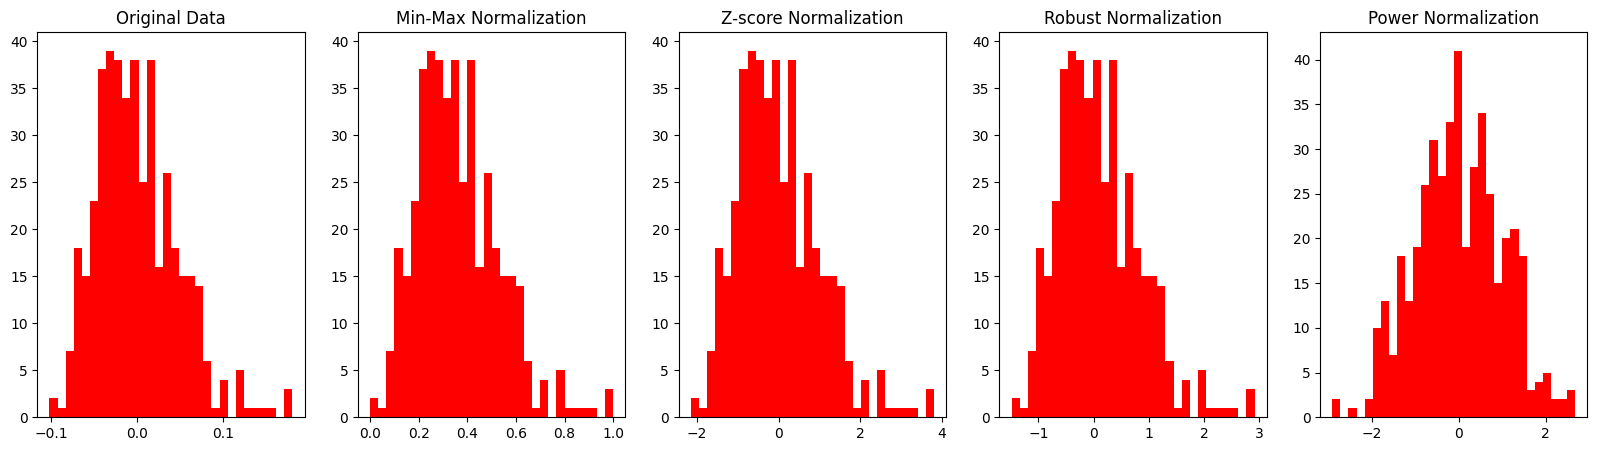

In [34]:
# Visualize the data after normalization using boxplot and scatter plot for each normalization technique.

#feature S3 scatter plots
fig,ax = plt.subplots(1,5,figsize=(20,5))
ax[0].scatter(Features[Selected_features[1]],Target, color='red')
ax[0].set_title("Original Data")
ax[1].scatter(Min_max_scaled[:,1],Target, color='red')
ax[1].set_title("Min-Max Normalization")
ax[2].scatter(Standard_scaled[:,1],Target, color='red')
ax[2].set_title("Z-score Normalization")
ax[3].scatter(Robust_scaled[:,1],Target, color='red')
ax[3].set_title("Robust Normalization")
ax[4].scatter(Power_scaled[:,1],Target, color='red')
ax[4].set_title("Power Normalization")

#feature S3 histograms
fig,ax = plt.subplots(1,5,figsize=(20,5))
ax[0].hist(Features[Selected_features[1]], bins=30, color='red')
ax[0].set_title("Original Data")
ax[1].hist(Min_max_scaled[:,1], bins=30, color='red')
ax[1].set_title("Min-Max Normalization")
ax[2].hist(Standard_scaled[:,1], bins=30, color='red')
ax[2].set_title("Z-score Normalization")
ax[3].hist(Robust_scaled[:,1], bins=30, color='red')
ax[3].set_title("Robust Normalization")
ax[4].hist(Power_scaled[:,1], bins=30, color='red')
ax[4].set_title("Power Normalization")


Text(0.5, 1.0, 'Power Normalization')

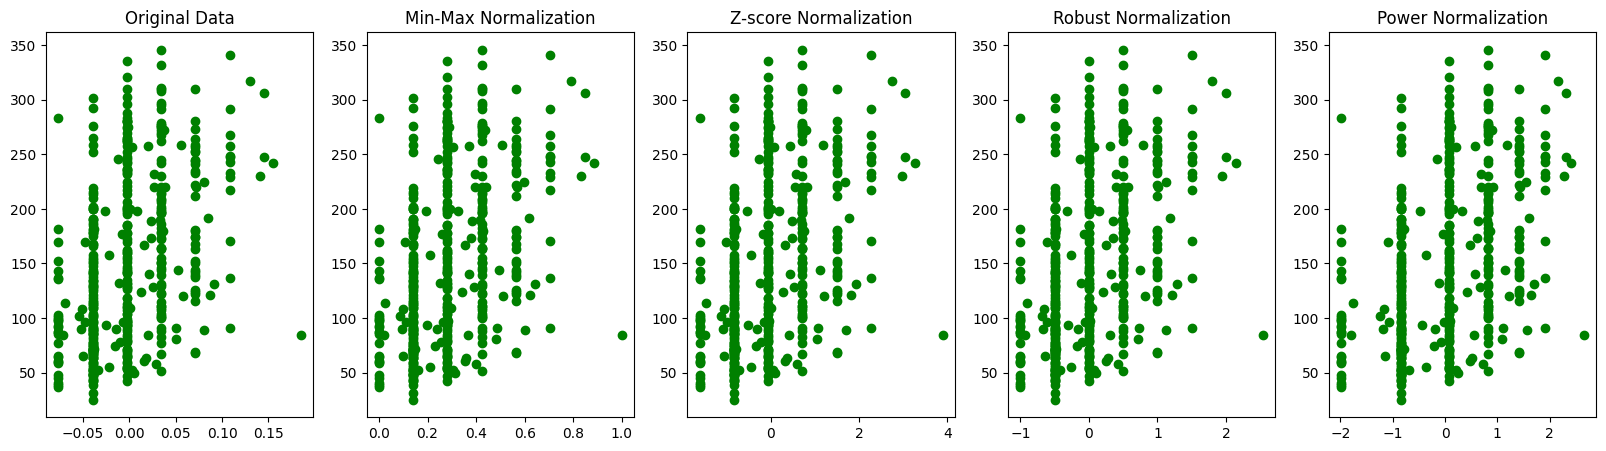

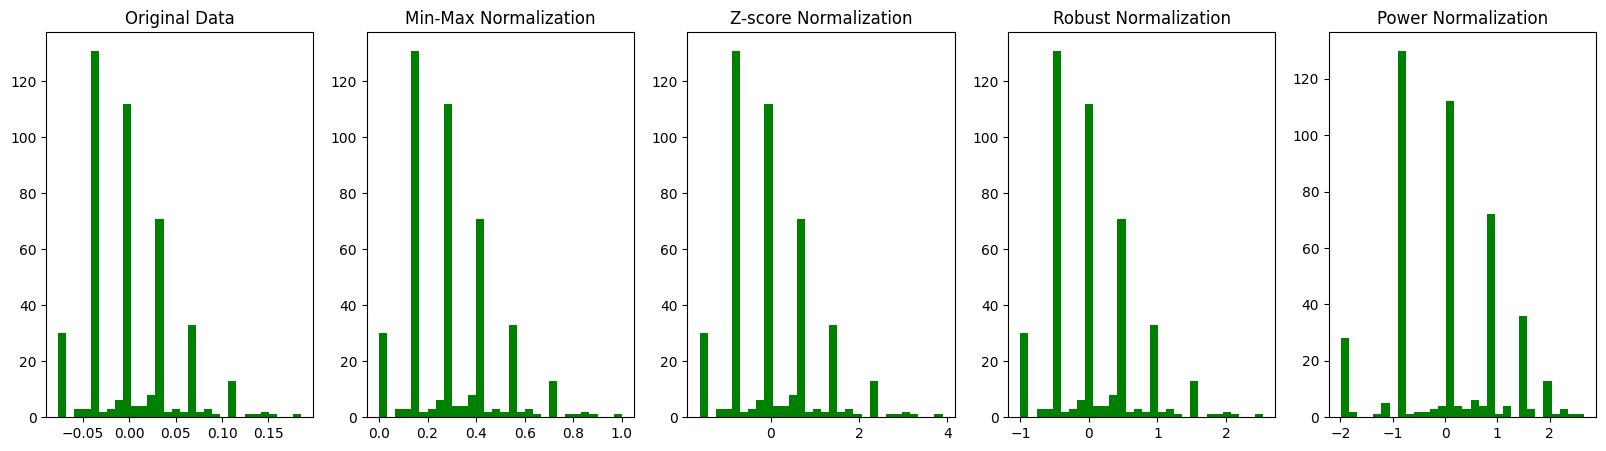

In [35]:
# Visualize the data after normalization using boxplot and scatter plot for each normalization technique.

#feature S4 scatter plots
fig,ax = plt.subplots(1,5,figsize=(20,5))
ax[0].scatter(Features[Selected_features[2]],Target, color='green')
ax[0].set_title("Original Data")
ax[1].scatter(Min_max_scaled[:,2],Target, color='green')
ax[1].set_title("Min-Max Normalization")
ax[2].scatter(Standard_scaled[:,2],Target, color='green')
ax[2].set_title("Z-score Normalization")
ax[3].scatter(Robust_scaled[:,2],Target, color='green')
ax[3].set_title("Robust Normalization")
ax[4].scatter(Power_scaled[:,2],Target, color='green')
ax[4].set_title("Power Normalization")

#feature S4 histograms
fig,ax = plt.subplots(1,5,figsize=(20,5))
ax[0].hist(Features[Selected_features[2]], bins=30, color='green')
ax[0].set_title("Original Data")
ax[1].hist(Min_max_scaled[:,2], bins=30, color='green')
ax[1].set_title("Min-Max Normalization")
ax[2].hist(Standard_scaled[:,2], bins=30, color='green')
ax[2].set_title("Z-score Normalization")
ax[3].hist(Robust_scaled[:,2], bins=30, color='green')
ax[3].set_title("Robust Normalization")
ax[4].hist(Power_scaled[:,2], bins=30, color='green')
ax[4].set_title("Power Normalization")


## Comparison of Scalars

### 1. Standard Scaler (`StandardScaler` / Z-Score)
* **How it Scales:** Centers the data at 0 with a standard deviation of 1 using the feature mean ($\mu$) and standard deviation ($\sigma$):
  $$X_{\text{scaled}} = \frac{X - \mu}{\sigma}$$
* **Linearity:** Linear transformation (preserves the original distribution shape).
* **Impact on Outliers:** **Highly Sensitive.** Extreme outliers skew both the mean and standard deviation, squishing the majority of inlier data into a compressed range to accommodate the distant outliers.

---

### 2. Min-Max Scaler (`MinMaxScaler`)
* **How it Scales:** Bounds the values strictly within a fixed range (typically $[0, 1]$) using the minimum ($X_{\text{min}}$) and maximum ($X_{\text{max}}$) values:
  $$X_{\text{scaled}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}$$
* **Linearity:** Linear transformation (preserves the original distribution shape).
* **Impact on Outliers:** **Extremely Sensitive.** An outlier will act as $X_{\text{max}}$ or $X_{\text{min}}$, compressing the vast majority of non-outlier data into a tiny band (e.g., between $0.0$ and $0.15$) and destroying local feature detail.

---

### 3. Robust Scaler (`RobustScaler`)
* **How it Scales:** Uses median and Interquartile Range ($\text{IQR} = Q_3 - Q_1$) to scale the feature:
  $$X_{\text{scaled}} = \frac{X - \text{median}}{\text{IQR}}$$
* **Linearity:** Linear transformation (preserves the original distribution shape).
* **Impact on Outliers:** **Resistant / Robust.** Because $Q_1$, Median, and $Q_3$ ignore data outside the 25th–75th percentile range, extreme outliers do not affect the scaling factor. Inliers remain well-spaced while outliers sit isolated further out on the axis.

---

### 4. Power Transformer (`PowerTransformer`)
* **How it Scales:** Applies non-linear mathematical transformations (power functions and logarithms) to stabilize variance and force skewed data into a symmetric Gaussian (bell-curve) shape centered at 0.
* **Linearity:** **Non-Linear transformation** (actively alters the distribution shape).
* **Impact on Outliers:** **Reduces Impact.** By applying logarithmic/power functions, it compresses heavy tails and pulls extreme values closer to the center cluster, making the feature more normal distribution-like.


### We can see that from above four transfroms the linear transforms only change the data point scales and does not affect the distribution shape or the skewness, the power transformer which is a non linear transformation, changes the scale and also the data distribution shape and its skewness

## Non linear power transformer is more robust to large ourliers because it mathematically compresses large error to compressed and therefore reducing the impact of outliers